# Assignment 3: Customer Intelligence System using Classification, Ensemble Learning and Clustering

## Objective

Develop an intelligence system using socio-economic and health indicators to identify countries requiring aid using machine learning techniques.

Algorithms Used:
- KMeans Clustering
- DBSCAN
- Random Forest
- XGBoost

In [317]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.metrics import (
    silhouette_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

# Load Dataset

In [318]:
df = pd.read_csv("Country-data.csv")

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


# Data Understanding

In [319]:
print("Shape:", df.shape)

print("\nColumns:\n")
print(df.columns)

print("\nDataset Info:\n")
df.info()

print("\nSummary Statistics:\n")
display(df.describe())

Shape: (167, 10)

Columns:

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB

Summary Statistics:



,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [320]:
print(df.isnull().sum())

print("\nDuplicate Rows:")

print(df.duplicated().sum())

print("\nUnique Countries:")

print(df["country"].nunique())

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Duplicate Rows:
0

Unique Countries:
167


# Exploratory Data Analysis (EDA)

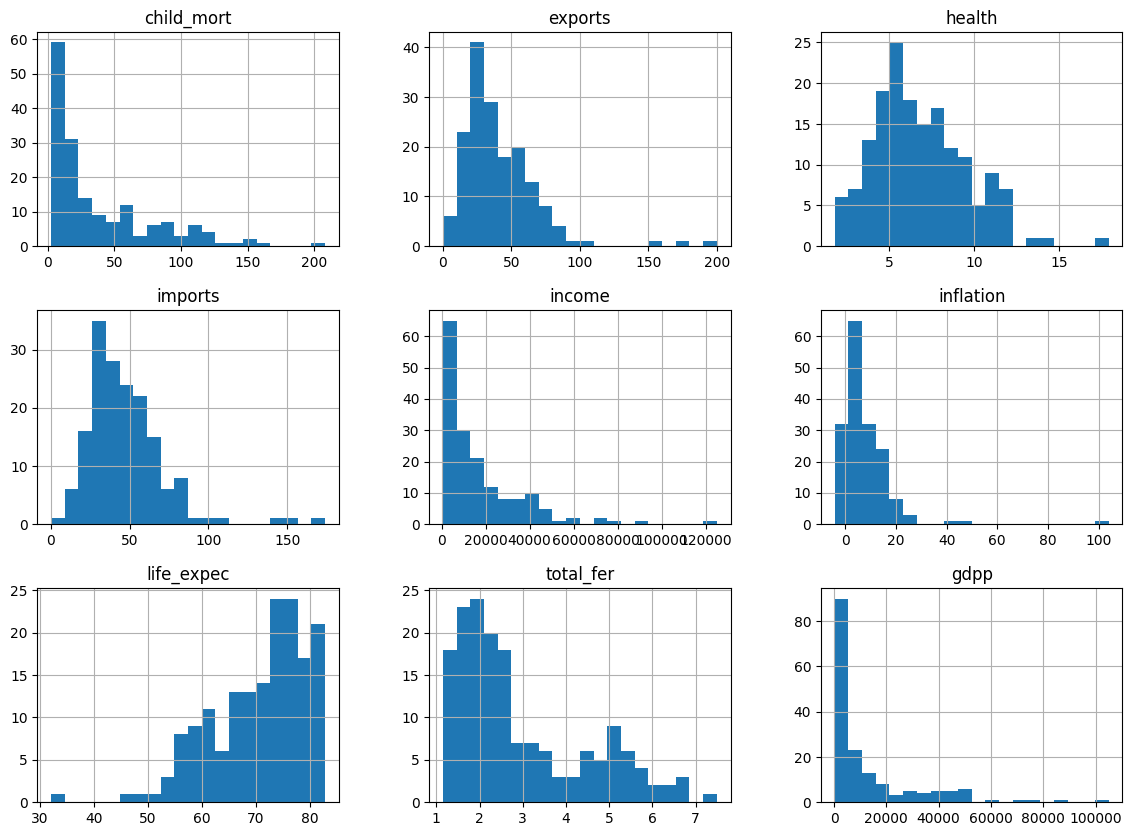

In [321]:
numeric_cols = df.drop(
    "country",
    axis=1
)

numeric_cols.hist(
    figsize=(14,10),
    bins=20
)

plt.show()

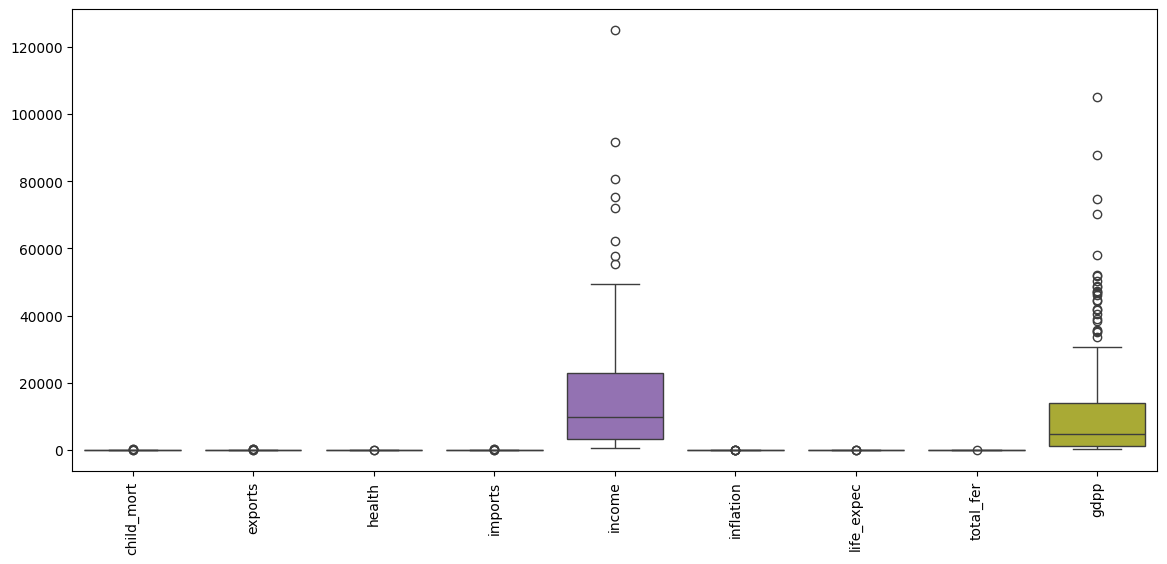

In [322]:
plt.figure(figsize=(14,6))

sns.boxplot(
    data=numeric_cols
)

plt.xticks(rotation=90)

plt.show()

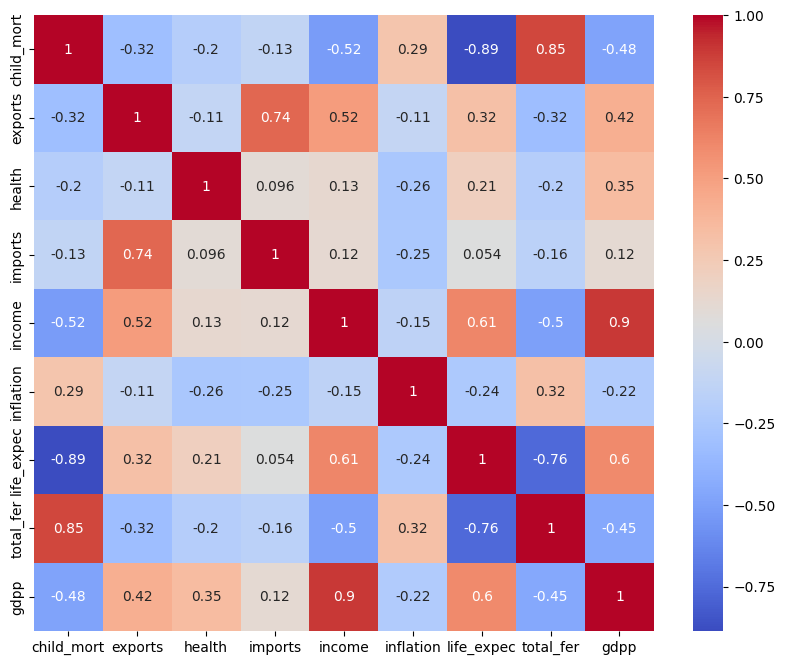

In [323]:
plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

# Feature Scaling

In [324]:
X = df.drop(
    "country",
    axis=1
)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# KMeans Clustering

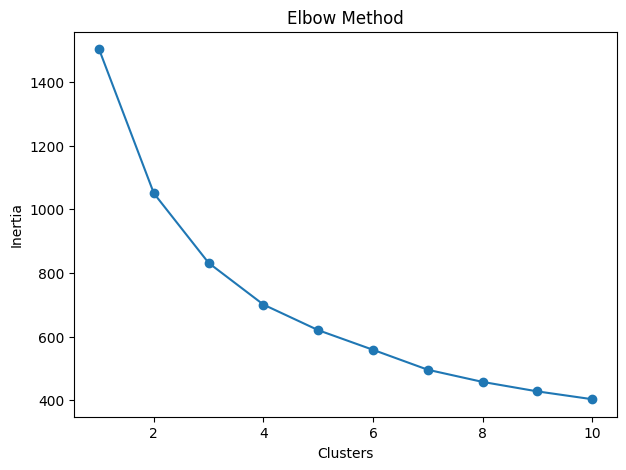

In [325]:
inertia = []

for i in range(1,11):

    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertia.append(
        model.inertia_
    )

plt.figure(figsize=(7,5))

plt.plot(
    range(1,11),
    inertia,
    marker="o"
)

plt.xlabel("Clusters")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

## Elbow Interpretation

The elbow point is selected where reduction in inertia becomes gradual. Based on the graph, K=3 clusters were selected.

In [326]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["KMeans_Cluster"] = kmeans.fit_predict(
    X_scaled
)

print(
    df["KMeans_Cluster"].value_counts()
)

KMeans_Cluster
2    84
1    47
0    36
Name: count, dtype: int64


In [327]:
score = silhouette_score(
    X_scaled,
    df["KMeans_Cluster"]
)

print(
    "Silhouette Score:",
    score
)

Silhouette Score: 0.28329575683463126


In [328]:
cluster_profile = df.groupby(
    "KMeans_Cluster"
).mean(
    numeric_only=True
)

display(cluster_profile)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
KMeans_Cluster,,,,,,,,,
0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979
2,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381


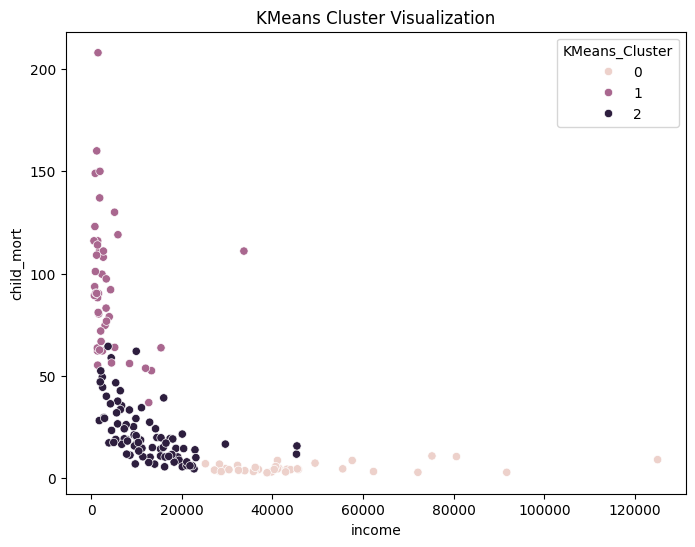

In [329]:
plt.figure(figsize=(8,6))

sns.scatterplot(

    x=df["income"],

    y=df["child_mort"],

    hue=df["KMeans_Cluster"]

)

plt.title(
    "KMeans Cluster Visualization"
)

plt.show()

# DBSCAN Clustering

In [330]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

df["DBSCAN_Cluster"] = dbscan.fit_predict(
    X_scaled
)

print(
    df["DBSCAN_Cluster"].value_counts()
)

DBSCAN_Cluster
 0    137
-1     30
Name: count, dtype: int64


In [331]:
noise_points = (
    df["DBSCAN_Cluster"] == -1
).sum()

print(
    "Noise Points:",
    noise_points
)

Noise Points: 30


# Classification Objective

Cluster labels generated from KMeans are used as target classes so classification models can predict cluster membership for unseen countries.

In [332]:
target = df["KMeans_Cluster"]

features = df.drop(
    columns=[
        "country",
        "KMeans_Cluster",
        "DBSCAN_Cluster"
    ]
)

In [333]:
X_train, X_test, y_train, y_test = train_test_split(

    features,

    target,

    test_size=0.2,

    random_state=42,

    stratify=target

)

In [334]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

# Random Forest Classification

In [335]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train_scaled,
    y_train
)

rf_pred = rf.predict(
    X_test_scaled
)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        rf_pred
    )
)

print(
    classification_report(
        y_test,
        rf_pred
    )
)

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



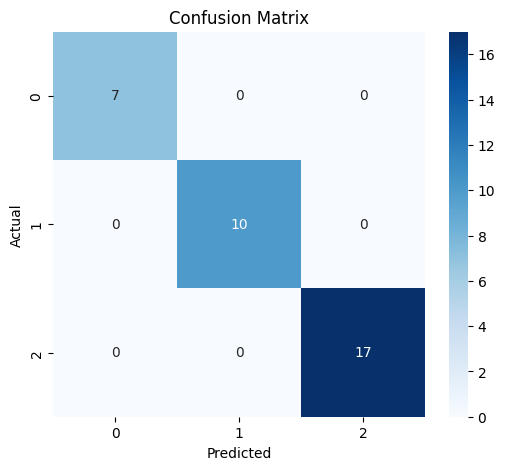

In [336]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "Confusion Matrix"
)

plt.show()

In [337]:
cv_scores = cross_val_score(
    rf,
    X_train_scaled,
    y_train,
    cv=5
)

print(
    "CV Scores:",
    cv_scores
)

print(
    "Average CV:",
    cv_scores.mean()
)

CV Scores: [0.92592593 0.92592593 1.         0.96153846 0.88461538]
Average CV: 0.9396011396011396


# XGBoost Classification

In [338]:
xgb = XGBClassifier(
    n_estimators=200,
    random_state=42,
    eval_metric="mlogloss"
)

xgb.fit(
    X_train_scaled,
    y_train
)

pred = xgb.predict(
    X_test_scaled
)

print(
    "XGBoost Accuracy:",
    accuracy_score(
        y_test,
        pred
    )
)

print(
    classification_report(
        y_test,
        pred
    )
)

XGBoost Accuracy: 0.9411764705882353
              precision    recall  f1-score   support

           0       1.00      0.86      0.92         7
           1       1.00      0.90      0.95        10
           2       0.89      1.00      0.94        17

    accuracy                           0.94        34
   macro avg       0.96      0.92      0.94        34
weighted avg       0.95      0.94      0.94        34



# Feature Importance

In [339]:
importance = pd.DataFrame({

"Feature":features.columns,

"Importance":rf.feature_importances_

})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

display(
    importance.head(10)
)

,Feature,Importance
0,child_mort,0.261935
8,gdpp,0.202125
7,total_fer,0.165920
6,life_expec,0.156307
4,income,0.146203
2,health,0.030472
5,inflation,0.014817
3,imports,0.012632
1,exports,0.009589


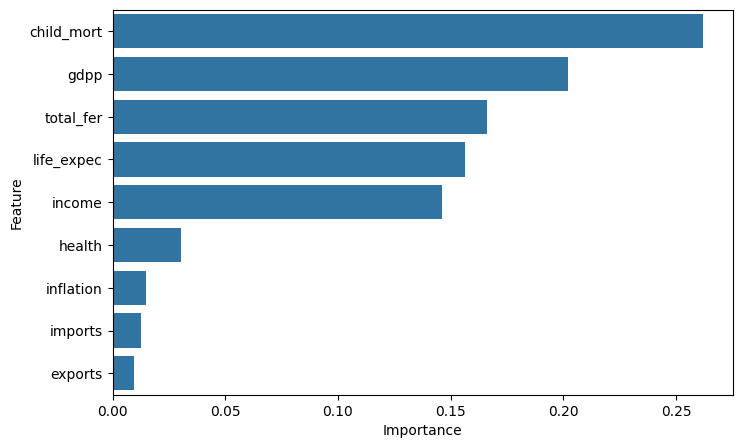

In [340]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.show()

# NGO Recommendation

In [341]:
high_risk_cluster = cluster_profile[
    "child_mort"
].idxmax()

priority = df[
    df["KMeans_Cluster"]
    ==
    high_risk_cluster
]

priority = priority.sort_values(
    "child_mort",
    ascending=False
)

priority[
[
"country",
"income",
"child_mort"
]
].head(15)

,country,income,child_mort
66,Haiti,1500,208.0
132,Sierra Leone,1220,160.0
32,Chad,1930,150.0
31,Central African Republic,888,149.0
97,Mali,1870,137.0
113,Nigeria,5150,130.0
112,Niger,814,123.0
3,Angola,5900,119.0
25,Burkina Faso,1430,116.0
37,"Congo, Dem. Rep.",609,116.0


# Final Insights

In [342]:
high_child_cluster = cluster_profile[
    "child_mort"
].idxmax()

high_income_cluster = cluster_profile[
    "income"
].idxmax()

high_gdpp_cluster = cluster_profile[
    "gdpp"
].idxmax()

underdeveloped_cluster = cluster_profile[
    "income"
].idxmin()

print("High Child Mortality Cluster:", high_child_cluster)

print("High Income Cluster:", high_income_cluster)

print("High GDP Cluster:", high_gdpp_cluster)

print("Underdeveloped Cluster:", underdeveloped_cluster)

High Child Mortality Cluster: 1
High Income Cluster: 0
High GDP Cluster: 0
Underdeveloped Cluster: 1


# Final Insights

1. Cluster 1 has the highest child mortality, indicating poor healthcare conditions and higher socio-economic vulnerability.

2. Cluster 0 has the highest income and GDP per capita, representing economically developed countries.

3. Cluster 1 appears underdeveloped because it shows lower income levels and weaker socio-economic indicators.

4. Countries belonging to Cluster 1 should be prioritized for aid allocation because they require greater humanitarian support and socio-economic support.

5. Clustering successfully segmented countries into meaningful groups, enabling better data-driven decision making for HELP International.



# Business Impact

This system helps HELP International prioritize countries for aid allocation by analyzing socio-economic and health indicators using machine learning techniques. The segmentation approach enables better resource allocation, faster identification of high-risk countries, and improved data-driven decision making.

# Final Conclusion

- KMeans successfully segmented countries into meaningful socio-economic groups.

- DBSCAN identified alternative cluster structures and noise points.

- Random Forest and XGBoost demonstrated strong predictive performance for cluster classification.

- Countries with poor socio-economic indicators and high child mortality were identified for prioritization.

- Machine learning techniques improved decision-making and resource allocation for HELP International.

# Overall Summary

This project successfully developed an intelligence system for HELP International using clustering, classification, and ensemble learning techniques. KMeans and DBSCAN were used to identify meaningful country segments, while Random Forest and XGBoost were applied to predict cluster membership. The analysis highlighted countries with poor socio-economic indicators, high child mortality, and lower income levels, enabling data-driven prioritization for aid allocation. Overall, machine learning techniques helped generate actionable insights and improve decision-making for humanitarian support.

# Overall Conclusion and Results

## Results

- KMeans clustering successfully segmented countries into distinct socio-economic groups.

- DBSCAN identified alternative patterns and noise points within the dataset.

- Cluster 1 showed higher child mortality and lower income levels, indicating vulnerable and underdeveloped countries.

- Cluster 0 showed higher income and GDP values, representing economically stronger countries.

- Random Forest and XGBoost achieved strong predictive performance in predicting cluster membership.

## Conclusion

This project successfully applied machine learning techniques to analyze socio-economic and health indicators for country segmentation. The system identified high-risk countries requiring humanitarian support and provided actionable insights for HELP International. The combination of clustering, classification, and ensemble learning improved data-driven decision making and resource allocation strategies.